In [191]:
import pandas as pd

In [192]:
df = pd.read_csv("/content/Churn_Modelling.csv")

In [193]:
print(df.shape)

(10000, 14)


In [194]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [195]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [196]:
df.duplicated().sum()

np.int64(0)

In [197]:
df['Exited'].value_counts()

,count
Exited,
0,7963
1,2037


In [198]:
df['Geography'].value_counts()

,count
Geography,
France,5014
Germany,2509
Spain,2477


In [199]:
df['Gender'].value_counts()

,count
Gender,
Male,5457
Female,4543


In [200]:
df.drop(columns=['RowNumber','CustomerId','Surname'],inplace=True)

In [201]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


1.Geography (3 categories → 2 columns)

If Geography has 3 values, say:

France,
Spain,
Germany

pd.get_dummies(..., drop_first=True) will create only 2 columns, for example:

Geography_Germany,
Geography_Spain

👉 The third category (France) is dropped and becomes the baseline:

If both columns = 0 → it means France

2.Gender (2 categories → 1 column)

If Gender has:

Male,
Female

You’ll get only 1 column, for example:

Gender_Male

👉 Interpretation:

1 → Male,
0 → Female (baseline)

In [202]:
#One Hot Encode
df = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True)

dummy_cols = [col for col in df.columns if 'Geography_' in col or 'Gender_' in col]
df[dummy_cols] = df[dummy_cols].astype(int)

In [203]:
df

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,0,0,1
9996,516,35,10,57369.61,1,1,1,101699.77,0,0,0,1
9997,709,36,7,0.00,1,0,1,42085.58,1,0,0,0
9998,772,42,3,75075.31,2,1,0,92888.52,1,1,0,1


In [204]:
#Scaling
from sklearn.model_selection import train_test_split
x = df.drop(columns=['Exited'])
y = df['Exited']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)

In [205]:
x

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,0,1
9996,516,35,10,57369.61,1,1,1,101699.77,0,0,1
9997,709,36,7,0.00,1,0,1,42085.58,0,0,0
9998,772,42,3,75075.31,2,1,0,92888.52,1,0,1


In [206]:
y

,Exited
0,1
1,0
2,1
3,0
4,0
...,...
9995,0
9996,0
9997,1
9998,1


In [207]:
x_train.shape

(8000, 11)

In [208]:
y_train.shape

(8000,)

In [209]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [210]:
x_train_scaled

array([[-0.23082038, -0.94449979, -0.70174202, ...,  1.71490137,
        -0.57273139,  0.91509065],
       [-0.25150912, -0.94449979, -0.35520275, ..., -0.58312392,
        -0.57273139, -1.09278791],
       [-0.3963303 ,  0.77498705,  0.33787579, ...,  1.71490137,
        -0.57273139, -1.09278791],
       ...,
       [ 0.22433188,  0.58393295,  1.3774936 , ..., -0.58312392,
        -0.57273139, -1.09278791],
       [ 0.13123255,  0.01077067,  1.03095433, ..., -0.58312392,
        -0.57273139, -1.09278791],
       [ 1.1656695 ,  0.29735181,  0.33787579, ...,  1.71490137,
        -0.57273139,  0.91509065]])

In [211]:
x_test_scaled

array([[-1.03768121,  0.77498705, -1.0482813 , ..., -0.58312392,
        -0.57273139,  0.91509065],
       [ 0.30708683, -0.46686456, -0.70174202, ..., -0.58312392,
        -0.57273139,  0.91509065],
       [-1.23422423,  0.29735181, -1.0482813 , ..., -0.58312392,
        -0.57273139, -1.09278791],
       ...,
       [-0.86182692, -0.46686456,  1.72403288, ..., -0.58312392,
         1.74601919,  0.91509065],
       [-0.30323097, -0.84897275, -1.0482813 , ...,  1.71490137,
        -0.57273139, -1.09278791],
       [ 0.04847759,  1.25262228,  1.3774936 , ...,  1.71490137,
        -0.57273139,  0.91509065]])

In [212]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [213]:
model = Sequential()

model.add(Dense(3,activation='sigmoid',input_dim = 11))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [214]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 3)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40 (160.00 B)

 Trainable params: 40 (160.00 B)

 Non-trainable params: 0 (0.00 B)

In [215]:
model.compile(loss='binary_crossentropy',optimizer='Adam')

In [216]:
history1 = model.fit(x_train_scaled,y_train,epochs=10)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.7782
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5984
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5079
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4715
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4554
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4465
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4404
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4359
Epoch 9/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4324
Epoch 10/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4297


In [217]:
model.layers[0].get_weights()

[array([[ 0.08691546, -0.0241785 ,  0.30911234],
        [ 1.3403428 , -0.8938921 , -1.9311678 ],
        [ 0.10553411,  0.16673112, -0.0347014 ],
        [-0.09446877, -0.47656968, -0.3955345 ],
        [-0.36543536, -0.1396254 ,  0.05290201],
        [-0.05440138,  0.07739389, -0.06152795],
        [-0.30132928,  1.0916071 ,  0.64469826],
        [-0.06745383, -0.04792688, -0.05759238],
        [ 0.30933842, -0.8097082 , -0.4450105 ],
        [-0.04483062, -0.09672701,  0.02081942],
        [-0.14849184,  0.5207086 ,  0.5087137 ]], dtype=float32),
 array([-0.45440027,  0.80346286,  0.72221345], dtype=float32)]

In [218]:
model.layers[1].get_weights()

[array([[ 0.7507782 ],
        [-1.0744827 ],
        [-0.99735737]], dtype=float32),
 array([-0.56612283], dtype=float32)]

In [219]:
model.predict(x_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


array([[0.12492012],
       [0.13652016],
       [0.1294987 ],
       ...,
       [0.07797612],
       [0.13494378],
       [0.36645508]], dtype=float32)

In [220]:
y_log = model.predict(x_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [221]:
import numpy as np
y_pred = np.where(y_log>0.5,1,0)

In [222]:
y_pred

array([[0],
       [0],
       [0],
       ...,
       [0],
       [0],
       [0]])

In [223]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.8085

In [235]:
import matplotlib.pyplot as plt
history1.history

{'loss': [0.7781895995140076,
  0.5984125733375549,
  0.5079309940338135,
  0.47153332829475403,
  0.4554435610771179,
  0.44647732377052307,
  0.4403841197490692,
  0.4358975887298584,
  0.4324210584163666,
  0.42967119812965393]}

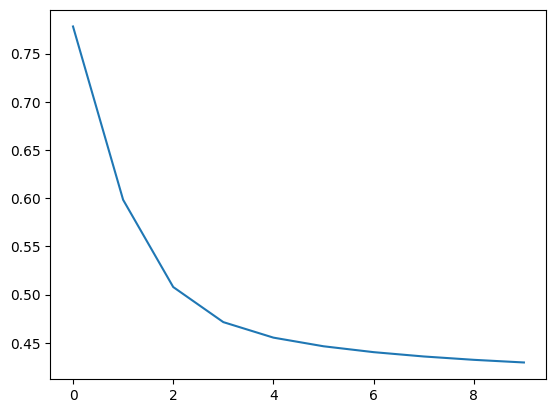

In [236]:
plt.plot(history1.history['loss'])

If we want to we can make changes in our model so that it's result gets better

like 1. increse no. of epoches

2. use Relu activation function for better result

3. Increase Nodes in hidden layer

4. Increase no. of layers

In [224]:
model1 = Sequential()
model1.add(Dense(11,activation='relu',input_dim = 11))
model1.add(Dense(11,activation='relu'))
model1.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [225]:
model1.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_22 (Dense)                │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [226]:
model1.compile(loss='binary_crossentropy',optimizer='Adam',metrics=['accuracy'])

In [227]:
history2 = model1.fit(x_train_scaled,y_train,epochs=100,validation_split=0.2)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6847 - loss: 0.5904 - val_accuracy: 0.8044 - val_loss: 0.4729
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8037 - loss: 0.4488 - val_accuracy: 0.8075 - val_loss: 0.4322
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8138 - loss: 0.4271 - val_accuracy: 0.8106 - val_loss: 0.4211
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8202 - loss: 0.4163 - val_accuracy: 0.8150 - val_loss: 0.4094
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8280 - loss: 0.4058 - val_accuracy: 0.8250 - val_loss: 0.3996
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8316 - loss: 0.3946 - val_accuracy: 0.8306 - val_loss: 0.3876
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8431 - loss: 0.3817 - val_accuracy: 0.8413 - val_loss: 0.3756
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8492 - loss: 0.3702 - val_accu

here if we observe so it is the case of overfitting because if our training accuracy is increase so the validation accuracy also have to increase.

In [228]:
y_log = model1.predict(x_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  


In [229]:
y_pred = np.where(y_log>0.5,1,0)

In [230]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.861

In [234]:
history2.history

{'accuracy': [0.6846874952316284,
  0.8037499785423279,
  0.8137500286102295,
  0.8201562762260437,
  0.8279687762260437,
  0.8315625190734863,
  0.8431249856948853,
  0.8492187261581421,
  0.8535937666893005,
  0.8537499904632568,
  0.8543750047683716,
  0.8568750023841858,
  0.8582812547683716,
  0.8571875095367432,
  0.860156238079071,
  0.8584374785423279,
  0.858593761920929,
  0.859375,
  0.8590624928474426,
  0.8589062690734863,
  0.8628125190734863,
  0.8582812547683716,
  0.8610937595367432,
  0.8606250286102295,
  0.8614062666893005,
  0.8617187738418579,
  0.8620312213897705,
  0.8614062666893005,
  0.8603125214576721,
  0.8626562356948853,
  0.8620312213897705,
  0.8615624904632568,
  0.8621875047683716,
  0.8621875047683716,
  0.8604687452316284,
  0.8628125190734863,
  0.86328125,
  0.8621875047683716,
  0.8631250262260437,
  0.8615624904632568,
  0.8634374737739563,
  0.8620312213897705,
  0.8634374737739563,
  0.8628125190734863,
  0.8612499833106995,
  0.86500000953674

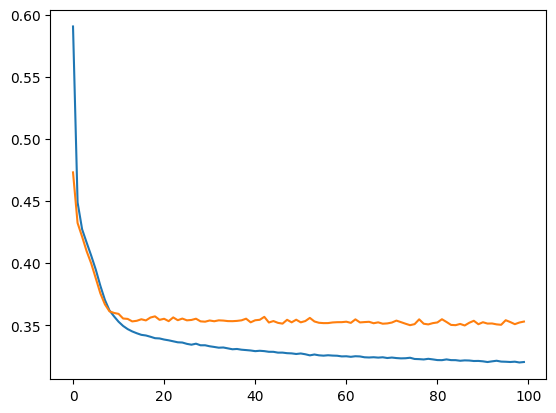

In [238]:
plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])

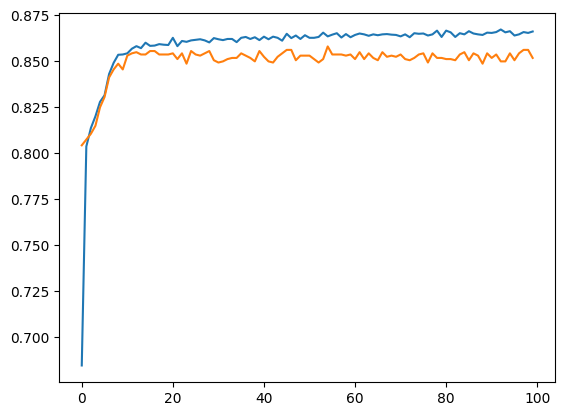

In [239]:
plt.plot(history2.history['accuracy'])
plt.plot(history2.history['val_accuracy'])